In [2]:
%pip install pandas numpy scipy seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.8 MB 8.2 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.8 MB 10.3 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.8 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.8 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 10.6 MB/s  0:00:00
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   -------- ------------------------------- 2.6/12.7 MB 13.4 MB/s eta 0:00:01
   ---------------- ----------------------- 5.2/12.7 MB 12.5 MB/s eta 0:00:01
   ------------------------- -------------- 8.1/12.7 MB 12.8 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import math
import re

In [5]:
page_a = pd.read_csv("data/eniac_a.csv")
page_b = pd.read_csv("data/eniac_b.csv")
page_c = pd.read_csv("data/eniac_c.csv")
page_d = pd.read_csv("data/eniac_d.csv")

### Data Exploration
Snapshot column has information on visits.
From page a and b considering clicks for "Show Now" and page c and d considering clicks for "See Deals"
Following the beow steps to form contingency table "observed_results"

In [7]:
page_a.head()

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,269,True,Homepage Version A - white SHOP NOW • http...
1,25,div,mySidebar,309,True,created 2021-09-14 • 14 days 0 hours 34 mi...
2,4,a,Mac,279,True,NaN
3,69,a,iPhone,246,True,NaN
4,105,a,Accessories,1235,True,NaN


In [9]:
page_a.shape

(57, 6)

In [10]:
page_a.columns.tolist()

['Element ID',
 'Tag name',
 'Name',
 'No. clicks',
 'Visible?',
 'Snapshot information']

In [11]:
print(page_a['Snapshot information'].iloc[1])

created 2021-09-14   •   14 days 0 hours 34 mins   •   25326 visits, 23174 clicks


In [12]:
page_a[page_a['Name'] == 'SHOP NOW']

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,106,a,SHOP NOW,512,True,NaN


In [13]:
page_b.head()

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,236,True,Homepage Version B - red SHOP NOW • https:...
1,25,div,mySidebar,304,True,created 2021-10-27 • 14 days 0 hours 34 mi...
2,4,a,Mac,268,True,NaN
3,69,a,iPhone,260,True,NaN
4,105,a,Accessories,1214,True,NaN


In [14]:
pages = [page_a, page_b, page_c, page_d]

In [15]:
page_b.shape

(57, 6)

In [16]:
page_a.columns.tolist()

['Element ID',
 'Tag name',
 'Name',
 'No. clicks',
 'Visible?',
 'Snapshot information']

In [17]:
page_b[page_b['Name'] == 'SHOP NOW']

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,126,a,SHOP NOW,281,True,NaN


In [20]:
page_a.head()

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,269,True,Homepage Version A - white SHOP NOW • http...
1,25,div,mySidebar,309,True,created 2021-09-14 • 14 days 0 hours 34 mi...
2,4,a,Mac,279,True,NaN
3,69,a,iPhone,246,True,NaN
4,105,a,Accessories,1235,True,NaN


In [24]:
page_c.shape

(57, 6)

In [21]:
page_c.columns.tolist()

['Element ID',
 'Tag name',
 'Name',
 'No. clicks',
 'Visible?',
 'Snapshot information']

In [22]:
page_c[page_c['Name'] == 'SEE DEALS']

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,127,a,SEE DEALS,527,True,NaN


In [23]:
page_d.head()

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,285,True,Homepage Version D - red SEE DEALS • https...
1,25,div,mySidebar,305,True,created 2021-10-27 • 14 days 0 hours 34 mi...
2,4,a,Mac,274,True,NaN
3,69,a,iPhone,243,True,NaN
4,105,a,Accessories,1267,True,NaN


In [26]:
page_d.shape

(57, 6)

In [25]:
page_d.columns.tolist()

['Element ID',
 'Tag name',
 'Name',
 'No. clicks',
 'Visible?',
 'Snapshot information']

In [27]:
page_d[page_d['Name'] == 'SEE DEALS']

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,128,a,SEE DEALS,193,True,NaN


# Hypothesis testing: Chi-Square Test within the Eniac case study

In this notebook we perform a chi-square test with the data from the Eniac case study, applying a post-hoc correction to perform pairwise tests and find the true winner.

## 1.&nbsp;State the Null Hypothesis and the Alternative Hypothesis.

Null Hypothesis - All versions have same CTR
Alternate Hypothesis - All versions do not have same CTR

## 2.&nbsp; Select an appropriate significance level alpha ($\alpha$).

In [29]:
alpha = 0.05

## 3.&nbsp; Collect data that is random and independent

The important pieces of information (clicks on each element of interest & visits on each page) are scattered around. Let's collect them. Where are the .csv files? 🥸

In [33]:
# The hard coded numbers came from filtering each page_X DataFrame. Reference under Data Exploration.
Click = [512, 281, 527, 193]
No_click = [25326 - 512, 24747 - 281, 24876 - 527, 25233 - 193]

observed_results = pd.DataFrame(
    [Click, No_click], columns=["A", "B", "C", "D"], index=["Click", "No-click"]
)
observed_results

,A,B,C,D
Click,512,281,527,193
No-click,24814,24466,24349,25040


## 4.&nbsp; Calculate the test result

In [34]:
chisq, p_value, df, expected = chi2_contingency(observed_results)
print(f"chi-square statistic: {chisq:.4f}")
print(f"p_value: {p_value}")
print(f"degrees of freedom: {df}")

chi-square statistic: 224.0188
p_value: 2.7161216607868712e-48
degrees of freedom: 3


In [40]:
pvalue

np.float64(6.450501398841206e-37)

In [35]:
print("Reject H0" if p_value < alpha else "Fail to reject H0")

Reject H0


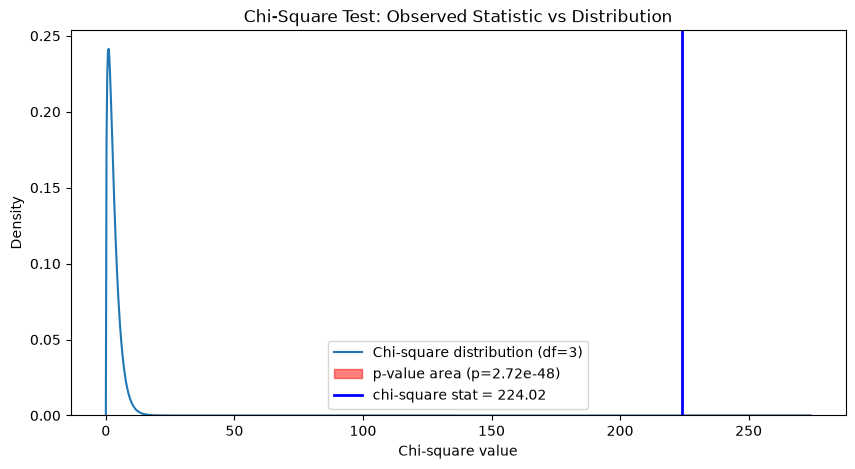

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

x = np.linspace(0, chisq + 50, 1000)
y = chi2.pdf(x, df=df)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label=f"Chi-square distribution (df={df})")

# Shade the p-value area (region more extreme than your chi-square statistic)
plt.fill_between(x, y, where=(x >= chisq), color='red', alpha=0.5, label=f"p-value area (p={p_value:.2e})")

# Vertical line for your chi-square statistic
plt.axvline(chisq, color='blue', linewidth=2, label=f"chi-square stat = {chisq:.2f}")

plt.title("Chi-Square Test: Observed Statistic vs Distribution")
plt.xlabel("Chi-square value")
plt.ylabel("Density")
plt.ylim(bottom=0)
plt.legend()
plt.show()

## 5.&nbsp; Interpret the test result

CTR is not the same across all four SHOP NOW/SEE DEALS button versions.

## How do we decide who's the winner?

A statistically significant result doesn't tell us which versions are best, it just tells us that at least one version is better or worse than another. To get more detailed comparisons we need to do post-hoc testing which performs a new test with each unique pair of versions.

Those unique pairs are:<br>
A B<br>
A C<br>
A D<br>
B C<br>
B D<br>
C D<br>

### Post-Hoc Testing

Post-hoc testing requires running a lot of tests. This increases our overall chance of getting type 1 errors, so to mitigate this we have to reduce our alpha during post-hoc testing. There are several strategies for this, but an easy one is to simply divide alpha by the number of tests being run:

In [43]:
num_versions = len(versions)
# Getting a count of all the ways they could be paired
num_comparisons = math.comb(num_versions, 2)
# Dividing alpha by the number of comparisons
adjusted_alpha = alpha/num_comparisons

In [37]:
num_tests = 3 + 2 + 1 + 0
adjusted_alpha = alpha / num_tests

In [38]:
from scipy.stats import chi2_contingency
from itertools import combinations

versions = ['A', 'B', 'C', 'D']
results = []

for v1, v2 in combinations(versions, 2):
    pair_table = observed_results[[v1, v2]]
    chisq, pvalue, df, expected = chi2_contingency(pair_table)
    significant = pvalue < adjusted_alpha
    results.append({'comparison': f'{v1} vs {v2}', 'p_value': pvalue, 'significant': significant})

posthoc_df = pd.DataFrame(results)
posthoc_df

,comparison,p_value,significant
0,A vs B,2.673088e-15,True
1,A vs C,4.648421e-01,False
2,A vs D,3.080898e-33,True
3,B vs C,6.955480e-18,True
4,B vs D,2.357337e-05,True
5,C vs D,6.450501e-37,True


In [39]:
ctrs = (observed_results / observed_results.sum()).iloc[0,:]
ctrs.name = 'CTR'
ctrs

A    0.020216
B    0.011355
C    0.021185
D    0.007649
Name: CTR, dtype: float64

## Guardrail Metrics

some additional guardrail metrics were collected which we should always check to make sure the primary metric, click-through-rate, isn't misleading. In addition to the ones on the LMS, you may have noticed that in the snapshot information there is a number for how many clicks in total were made on the webpage, which allows us to calculate the bounce rate as well. These guardrail metrics may also be able to help us decide between version A and C.

In [49]:
guardrail_metrics = {}

If you knew you wanted to collect the bounce rate it would be easy to incorporate into the earlier code that was gathering the visits. Best practice would be to edit the code above to reduce redundancy, but for teaching purposes, to make this easier to follow, we will just repeat the process of looping through the snapshots down here, this time gathering the total clicks and calculating the bounce rate.

In [52]:
# Function for fetching visits and clicks data
# to calculate bounce rate
def get_bounce_rate(version):
    
    # Read the CSV file
    page_df = pd.read_csv(f'data/eniac_{version.lower()}.csv')
    
    # Get snapshot information
    page_info = page_df['Snapshot information'].iloc[1]
    
    # Extract number of visits
    visits = re.findall(
        pattern=r'(\d+) visits',
        string=page_info
    )[0]
    
    # Extract number of clicks
    clicks = re.findall(
        pattern=r'(\d+) clicks',
        string=page_info
    )[0]
    
    # Calculate bounce rate
    bounce_rate = 1 - (int(clicks) / int(visits))
    
    return bounce_rate


# Loop through versions and calculate bounce rates
guardrail_metrics['Bounce Rate'] = [
    get_bounce_rate(version) for version in versions
]

# Display the results
guardrail_metrics

{'Bounce Rate': [0.08497196556898046,
  0.09455691598981697,
  0.0741678726483358,
  0.09868029960765667]}

In [53]:
# Manually estimated from graphs 
guardrail_metrics['Drop-Off Rate'] = [0.098, None, 0.125, 0.122]
guardrail_metrics['Homepage-Return Rate'] = [0.0525, None, 0.047, 0.026]

In [54]:
guardrail_metrics_df = pd.DataFrame(guardrail_metrics, index=versions)
guardrail_metrics_df

,Bounce Rate,Drop-Off Rate,Homepage-Return Rate
A,0.084972,0.098,0.0525
B,0.094557,NaN,NaN
C,0.074168,0.125,0.0470
D,0.098680,0.122,0.0260


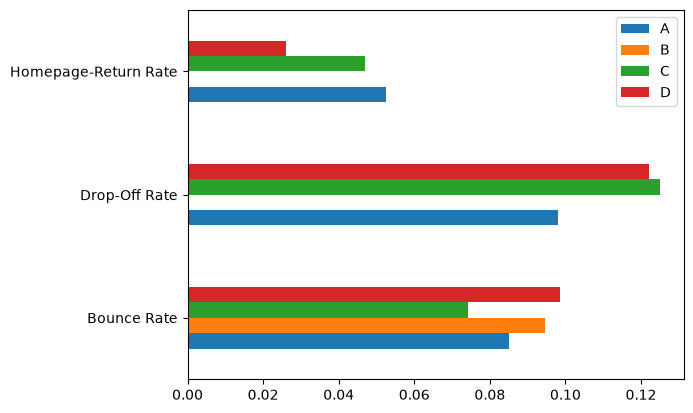

In [55]:
# Plotting the guardrail scores (smaller numbers are better)
guardrail_metrics_df.T.plot.barh();

We could also include the primary metric to compare with all our KPIs

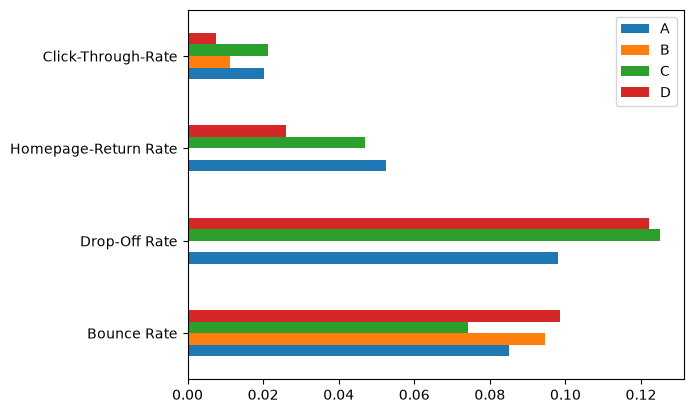

In [57]:
# Plotting all metrics
all_metrics = guardrail_metrics_df.copy()
all_metrics['Click-Through-Rate'] = ctrs
all_metrics.T.plot.barh();

The guardrail metrics aren't showing any signs of the click-through-rate being misleading so we are good to trust the original results and stick with version A <br><br>
When it comes to tie-breaking, in this case, the differences between A and C with these guardrail metrics are not consistent enough to convince us to move from A to C. A has a better drop-off rate and C has slightly better homepage return and bounce rates. Altogether we don't have strong evidence that changing versions will improve UX. If we did want to use these metrics for tie-breaking though, we would need to check if the differences between A and C are statistically significant.

Calculating statistical significance of differences for guardrail metrics

Since we want to run tests for three guardrail metrics we should divide alpha by 3. <br>

By performing another set of tests we are adding more opportunities for type 1 errors, but generally since the click through rates (our primary performance metric) of these two versions have been found to be very similar, the consequences of making a type 1 error with these tie-breaking tests are much less severe.

In [58]:
num_tests = 3
tie_break_alpha = alpha/num_tests

Right now we have the data as percentages (rates) so we'll need to use the number of visits to turn those rates into contingency tables that we can actually calculate the chi-squared for:

In [62]:
import pandas as pd

page_df = pd.read_csv('data/eniac_a.csv')

print(page_df.columns.tolist())
print()
print(page_df[['Name', 'No. clicks']].to_string(index=False))

['Element ID', 'Tag name', 'Name', 'No. clicks', 'Visible?', 'Snapshot information']

                Name  No. clicks
               ENIAC         269
           mySidebar         309
                 Mac         279
              iPhone         246
         Accessories        1235
   Chargers & Cables        1261
  iPhone Accessories        1226
   Watch Accessories        1261
     Mac Accessories        1308
              AirTag         206
                iPad         186
               Watch         212
             Storage         198
            Services         177
             Contact         266
          Newsletter          56
           Subscribe          56
       w3-padding-64         324
w3-display-container         312
               Jeans         924
  w3-display-topleft         327
            SHOP NOW         512
      iphone13_cover         877
       abstract-case         912
             airpods         921
          watch-lgtb         843
          blue-strap   

In [63]:
import pandas as pd
import re

def get_bounce_rate(version):
    page_df = pd.read_csv(f'data/eniac_{version.lower()}.csv')
    page_info = page_df['Snapshot information'].iloc[1]

    visits = int(re.findall(r'(\d+) visits', page_info)[0])
    clicks = int(re.findall(r'(\d+) clicks', page_info)[0])

    return 1 - (clicks / visits)

In [66]:
# Versions
versions = ['A', 'B', 'C', 'D']


# ---------------------------------------------------------
# Get snapshot information
# ---------------------------------------------------------
def get_snapshot_info(version):
    page_df = pd.read_csv(
        f'data/eniac_{version.lower()}.csv'
    )

    page_info = page_df['Snapshot information'].iloc[1]

    visits = int(
        re.findall(r'(\d+) visits', page_info)[0]
    )

    clicks = int(
        re.findall(r'(\d+) clicks', page_info)[0]
    )

    return visits, clicks


# ---------------------------------------------------------
# 1. Bounce Rate
# ---------------------------------------------------------
def get_bounce_rate(version):

    visits, clicks = get_snapshot_info(version)

    return 1 - (clicks / visits)


# ---------------------------------------------------------
# 2. Drop-Off Rate
# ---------------------------------------------------------
def get_drop_off_rate(version):

    visits, clicks = get_snapshot_info(version)

    # Visitors who did not click anything
    drop_off = visits - clicks

    return drop_off / visits


# ---------------------------------------------------------
# 3. Homepage Return Rate
# ---------------------------------------------------------
def get_homepage_return_rate(version):

    page_df = pd.read_csv(
        f'data/eniac_{version.lower()}.csv'
    )

    page_info = page_df['Snapshot information'].iloc[1]

    visits = int(
        re.findall(r'(\d+) visits', page_info)[0]
    )

    # Find homepage element
    homepage = page_df[
        page_df['Name'].isin(['ENIAC'])
    ]

    if homepage.empty:
        raise ValueError(
            f"Homepage element 'ENIAC' not found for version {version}"
        )

    returned = homepage['No. clicks'].iloc[0]

    return returned / visits


# ---------------------------------------------------------
# Create guardrail metrics DataFrame
# ---------------------------------------------------------
guardrail_metrics_df = pd.DataFrame(
    index=versions,
    columns=[
        'Bounce Rate',
        'Drop-Off Rate',
        'Homepage-Return Rate'
    ],
    dtype=float
)


# Calculate all metrics
for version in versions:

    guardrail_metrics_df.loc[
        version, 'Bounce Rate'
    ] = get_bounce_rate(version)

    guardrail_metrics_df.loc[
        version, 'Drop-Off Rate'
    ] = get_drop_off_rate(version)

    guardrail_metrics_df.loc[
        version, 'Homepage-Return Rate'
    ] = get_homepage_return_rate(version)


# Display results
display(guardrail_metrics_df)

,Bounce Rate,Drop-Off Rate,Homepage-Return Rate
A,0.084972,0.084972,0.010621
B,0.094557,0.094557,0.009537
C,0.074168,0.074168,0.011577
D,0.098680,0.098680,0.011295


Now we can calculate the statistical significance for these metrics

In [70]:
from scipy.stats import chi2_contingency

for metric, table in contingency_tables.items():

    # Run chi-square test
    chisq, pvalue, df, expected = chi2_contingency(table)

    print(f"\n{metric}")
    print(f"Chi-square statistic: {chisq:.4f}")
    print(f"p-value: {pvalue:.4f}")

    if pvalue < tie_break_alpha:

        # Only compare versions actually present in this table
        versions_tested = list(table.columns)

        # Get their rates
        rates = guardrail_metrics_df.loc[
            versions_tested, metric
        ]

        # Lower rate is better for these guardrail metrics
        better = rates.idxmin()

        print(
            f"Version {better.upper()} has the lower {metric} rate "
            f"among the versions tested."
        )

    else:
        print(
            f"The difference in {metric} was not statistically significant."
        )


Bounce Rate
Chi-square statistic: nan
p-value: nan
The difference in Bounce Rate was not statistically significant.


# Conclusion

Versions A and C are statistically tied for the highest CTR, both significantly outperforming Versions B and D. Version D performs significantly less than all other versions.